In [1]:
# Cell 1 — Upload the aggregated CSVs into the Colab session
# Run this, then select all_spots.csv AND all_tracks.csv in the file dialog.
from google.colab import files

uploaded = files.upload()          # browser dialog; you can pick both at once
print("\nUploaded:", list(uploaded.keys()))

Saving all_spots.csv to all_spots.csv
Saving all_tracks.csv to all_tracks.csv

Uploaded: ['all_spots.csv', 'all_tracks.csv']


In [2]:
# =====================================================================
# Cell 2 — Read the two CSVs into pandas DataFrames
# ---------------------------------------------------------------------
# TrackMate CSVs carry a FOUR-ROW header before the data begins:
#   row 0 : ALL_CAPS machine keys   <- we keep these as the column names
#   row 1 : human-readable names    \
#   row 2 : short abbreviations      |  three extra header rows that we
#   row 3 : units                   /   must skip or they'd be read as data
#
# pandas applies `skiprows` first, then `header` to what remains:
#   header=0        -> use row 0 (the KEYS) as column names
#   skiprows=[1,2,3]-> drop the name/abbrev/units rows
# This is the standard TrackMate read pattern.
#
# NOTE: these files were concatenated across 10 source images and have an
# extra SOURCE_IMAGE column prepended by an upstream merge step (NOT by the
# TrackMate exporter). Otherwise this is stock TrackMate output.
# =====================================================================
import pandas as pd

# Identify which uploaded file is which BY NAME, so upload order doesn't matter.
# (`uploaded` was created in Cell 1; its keys are the filenames now in /content/.)
spots_file  = next(f for f in uploaded if "spots"  in f.lower())
tracks_file = next(f for f in uploaded if "tracks" in f.lower())

# Read both, applying the 4-row-header rule explained above.
spots  = pd.read_csv(spots_file,  header=0, skiprows=[1, 2, 3])
tracks = pd.read_csv(tracks_file, header=0, skiprows=[1, 2, 3])

# Confirm what we loaded — a sanity check before we trust anything downstream.
print(f"spots  : {spots.shape[0]:>5} rows x {spots.shape[1]} cols")
print(f"tracks : {tracks.shape[0]:>5} rows x {tracks.shape[1]} cols")
print(f"source images: {spots['SOURCE_IMAGE'].nunique()}")

spots  :   619 rows x 64 cols
tracks :    30 rows x 30 cols
source images: 9


In [3]:
# =====================================================================
# Cell 3 — Orientation & integrity checks  (look before we leap)
# ---------------------------------------------------------------------
# This cell does NOT do analysis. It (a) verifies the assumptions the rest
# of the notebook relies on, and (b) adds ONE derived column we'll reuse:
# `is_manual`. Read the four printouts before trusting anything downstream.
# =====================================================================

# --- 1. Region label lives PER-SPOT in MEDIAN_INTENSITY_CH5 -------------
#   1.0 = injured zone, 2.0 = uninjured zone, 0.0 = outside annotated tissue.
#   We print the raw split so the size of the "0.0 / outside tissue" group is
#   explicit. What to DO with those 0.0 spots is a later decision, not now.
print("1) Region label counts (MEDIAN_INTENSITY_CH5):")
print(spots["MEDIAN_INTENSITY_CH5"].value_counts(dropna=False).sort_index(), "\n")

# --- 2. Manual-curation flag, read off the morphology ------------------
#   Hand-added TrackMate spots are perfect circles (default radius 5):
#   CIRCULARITY == 1.0 exactly, with AREA = pi*5^2 = 78.54. MaskDetector
#   spots inherit the real cell outline, so their circularity is < 1.
#   We FLAG (not drop): these are real cells -> valid for COUNTING and for
#   POSITION-based motility, but they carry placeholder shape -> must be
#   excluded from any morphology metric later.
spots["is_manual"] = spots["CIRCULARITY"] == 1.0
n_manual = int(spots["is_manual"].sum())
print(f"2) Manual spots: {n_manual} / {len(spots)} ({100*n_manual/len(spots):.1f}%)\n")

# --- 3. Track identity = (SOURCE_IMAGE, TRACK_ID), NOT TRACK_ID alone ---
#   Concatenating 10 images makes TRACK_ID values collide (each image
#   restarts numbering). The true count of distinct cells is the number of
#   (SOURCE_IMAGE, TRACK_ID) pairs -- we group on BOTH everywhere downstream.
print(f"3) distinct TRACK_ID alone        : {spots['TRACK_ID'].nunique()}")
print(f"   distinct (SOURCE_IMAGE,TRACK_ID): "
      f"{spots.groupby(['SOURCE_IMAGE','TRACK_ID']).ngroups}  <- true track count\n")

# --- 4. Sampling interval differs between images (must be accounted for) -
#   POSITION_T = absolute time in seconds; FRAME = integer index. Some images
#   are 30-min sampled, others 40-min, so the same FRAME is a different real
#   time across images. Fine for per-image plots; reconciled later for
#   cross-image averaging. interval_min derived as last_time / last_frame.
per_image = (spots.groupby("SOURCE_IMAGE")
                  .agg(n_frames=("FRAME", lambda s: int(s.max()) + 1),
                       max_T_s =("POSITION_T", "max")))
per_image["interval_min"] = (per_image["max_T_s"]
                             / (per_image["n_frames"] - 1) / 60).round(1)
print("4) Per-image sampling:")
print(per_image)

1) Region label counts (MEDIAN_INTENSITY_CH5):
MEDIAN_INTENSITY_CH5
0.0    106
1.0    213
2.0    139
3.0    161
Name: count, dtype: int64 

2) Manual spots: 129 / 619 (20.8%)

3) distinct TRACK_ID alone        : 20
   distinct (SOURCE_IMAGE,TRACK_ID): 30  <- true track count

4) Per-image sampling:
                                                    n_frames       max_T_s  \
SOURCE_IMAGE                                                                 
20250724_20250724_Position001_20250724_20250724...        23  52801.718750   
20250724_20250724_Position005_20250724_20250724...        23  52801.557617   
20250724_20250724_Position007_20250724_20250724...        23  52801.471680   
20250724_20250724_Position008_20250724_20250724...        23  52801.450195   
20251017_20251017_Position005-good_20251017_202...        27  46801.764648   
20251017_20251017_Position008_20251017_20251017...        33  57602.320312   
20251017_20251017_Position009_20251017_20251017...        33  57602.320312  

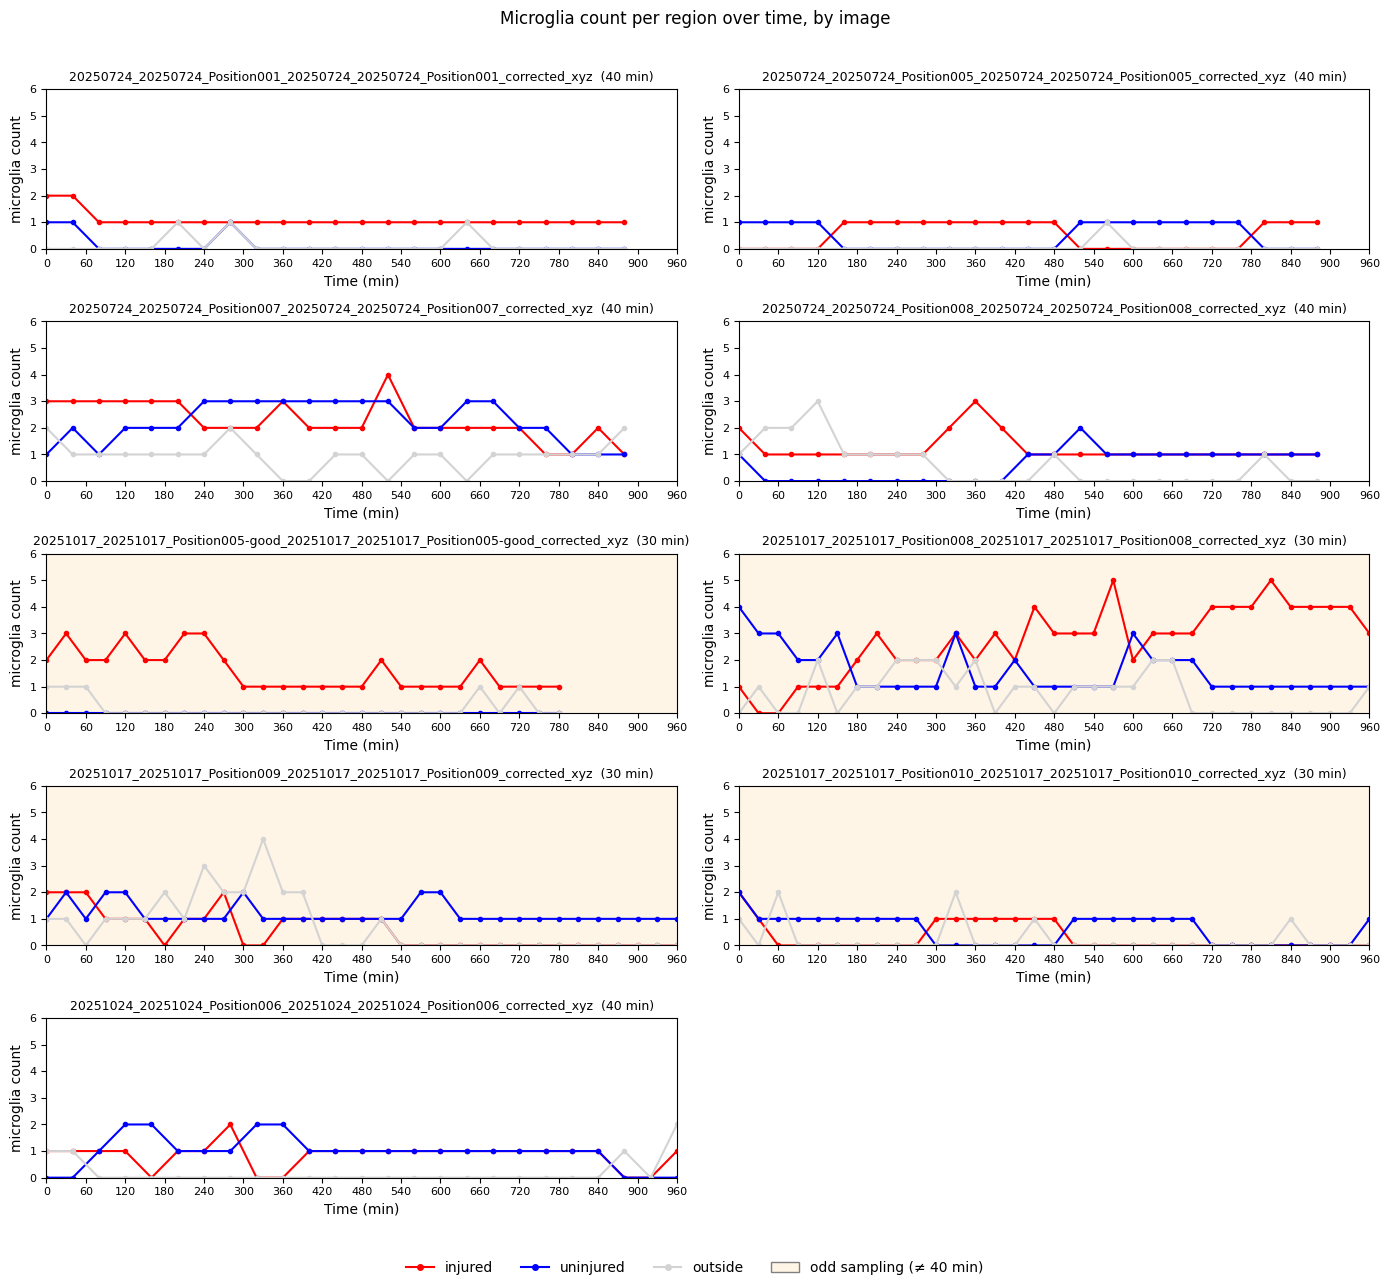

In [7]:
# =====================================================================
# Cell 4 — Per-image microglia counts over real time (small multiples)
# ---------------------------------------------------------------------
# COUNTS use the SIMPLE injured-vs-uninjured contrast: the core (3) folds
# INTO injured, because it's part of the injured side and splitting it
# would understate the injured count. The finer core/penumbra split is
# kept in `region_fine` for the motility analysis later.
#
# Choices baked in (as discussed):
#   * X = real time in minutes (frame x that image's sampling interval),
#     ticks every TICK_MIN min, labelled on EVERY subplot.
#   * Y = identical on every subplot (0..YMAX), labelled on EVERY subplot.
#   * Groups by per-spot MEDIAN_INTENSITY_CH5:
#       uninjured (1) = blue, injured (2 OR 3) = red, outside (0) = grey
#   * Manual AND automated spots both counted (a manual spot is a real cell).
#   * Odd-cadence images get a light background tint.
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---- knobs you might tweak -------------------------------------------
TICK_MIN = 60                       # x-tick spacing in minutes (30 or 60)
NCOLS    = 2                        # number of subplot columns
COLORS   = {"injured": "red", "uninjured": "blue", "outside": "lightgrey"}
TINT     = "#fff5e6"                # background for odd-cadence images
ORDER    = ["injured", "uninjured", "outside"]   # fixed draw/legend order

# ---- region labels: two granularities from the same per-spot label ----
#   region      : SIMPLE injured-vs-uninjured (for COUNTS) — core -> injured
#   region_fine : full gradient (for MOTILITY later) — penumbra vs core kept
REGION      = {0.0: "outside", 1.0: "uninjured", 2.0: "injured",   3.0: "injured"}
REGION_FINE = {0.0: "outside", 1.0: "uninjured", 2.0: "penumbra",  3.0: "core"}
spots["region"]      = spots["MEDIAN_INTENSITY_CH5"].map(REGION)
spots["region_fine"] = spots["MEDIAN_INTENSITY_CH5"].map(REGION_FINE)

# ---- counts per (image, frame, region) -------------------------------
# size() = number of spots = number of cells (one spot per cell per frame).
counts = spots.groupby(["SOURCE_IMAGE", "FRAME", "region"]).size()

YMAX = int(counts.max()) + 1        # shared y-axis: busiest region-frame + headroom

# per_image (from Cell 3) gives n_frames + interval_min per image.
intervals     = per_image["interval_min"]
mode_interval = intervals.mode().iloc[0]                 # the majority cadence
XMAX = float((per_image["n_frames"] - 1).mul(intervals).max())   # longest image, min

# ---- figure: one panel per image -------------------------------------
images = sorted(spots["SOURCE_IMAGE"].unique())
nrows  = int(np.ceil(len(images) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS, figsize=(7 * NCOLS, 2.6 * nrows))
axes = axes.ravel()

for ax, img in zip(axes, images):
    interval = intervals[img]
    sub      = spots[spots["SOURCE_IMAGE"] == img]
    frames   = np.arange(int(sub["FRAME"].max()) + 1)
    t_min    = frames * interval                          # real-time x for THIS image

    # counts per region, reindexed so empty frames read 0 (a line, not a gap)
    piv = (sub.groupby(["FRAME", "region"]).size()
              .unstack("region")
              .reindex(index=frames, columns=ORDER)
              .fillna(0))

    for grp in ORDER:
        ax.plot(t_min, piv[grp], marker="o", ms=3, lw=1.5,
                color=COLORS[grp], label=grp)

    if interval != mode_interval:                         # odd cadence -> tint
        ax.set_facecolor(TINT)

    ax.set_title(f"{img}  ({interval:.0f} min)", fontsize=9)
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("microglia count")
    ax.set_ylim(0, YMAX)
    ax.set_xlim(0, XMAX)
    ax.set_xticks(np.arange(0, XMAX + 1, TICK_MIN))
    ax.tick_params(labelsize=8)

for ax in axes[len(images):]:        # blank any leftover panels
    ax.axis("off")

# shared legend (incl. what the tint means)
handles = [plt.Line2D([], [], color=COLORS[g], marker="o", ms=4, label=g) for g in ORDER]
handles.append(Patch(facecolor=TINT, edgecolor="grey",
                     label=f"odd sampling (\u2260 {mode_interval:.0f} min)"))
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False)

fig.suptitle("Microglia count per region over time, by image", fontsize=12)
fig.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

images contributing per time bin:
bin
0      9
60     9
120    9
180    9
240    9
300    9
360    9
420    9
480    9
540    9
600    9
660    9
720    9
780    9
840    8
900    4
960    4
Name: n_images, dtype: int64

kept 15/17 bins (>= 75% of 9 images contributing)


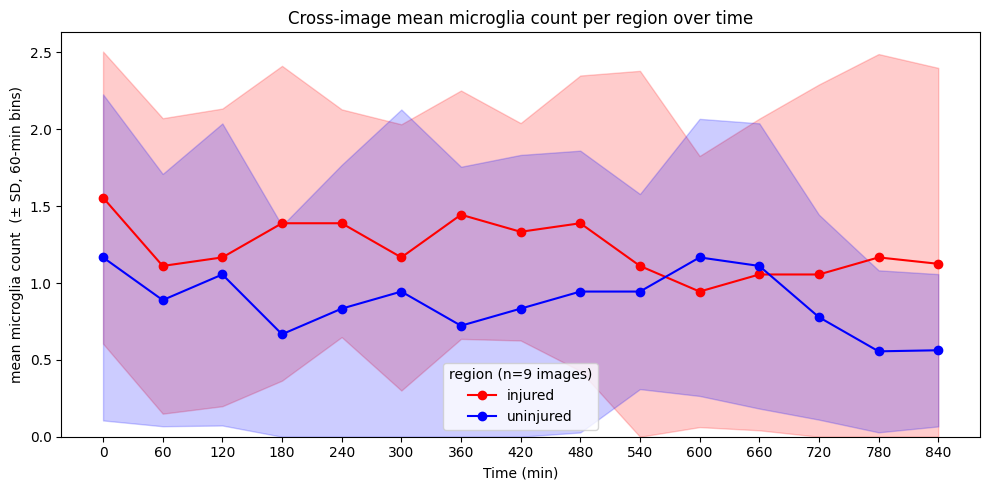

In [8]:
# =====================================================================
# Cell 5 — Cross-image summary: mean +/- SD count per region over time
# ---------------------------------------------------------------------
# Pools all images into one curve per region. Cadence (30 vs 40 min) is
# handled by BINNING onto a common grid: average per-frame counts within
# each image's bin first, THEN mean +/- SD across images per bin.
# Depends on Cells 3-4 (spots["region"], per_image, intervals, COLORS, ORDER).
# =====================================================================
BIN_MIN        = 60      # common time-bin width, minutes
SHOW_OUTSIDE   = False   # include the 'outside tissue' region in the plot?
MIN_IMAGE_FRAC = 0.75     # drop bins where < this fraction of images contribute
                         # (the timelapse tail is averaged over few fish -> noisy)

# --- 1) per-image, per-bin MEAN count per region ----------------------
per_fish_bin = []
for img in images:
    interval = intervals[img]
    sub      = spots[spots["SOURCE_IMAGE"] == img]
    frames   = np.arange(int(sub["FRAME"].max()) + 1)
    piv = (sub.groupby(["FRAME", "region"]).size()
              .unstack("region")
              .reindex(index=frames, columns=ORDER)
              .fillna(0))
    piv["bin"] = ((frames * interval) // BIN_MIN * BIN_MIN).astype(int)
    g = piv.groupby("bin")[ORDER].mean()
    g["SOURCE_IMAGE"] = img
    per_fish_bin.append(g.reset_index())
per_fish_bin = pd.concat(per_fish_bin, ignore_index=True)

# --- 2) across images: mean, SD, n per bin ----------------------------
summary  = per_fish_bin.groupby("bin")[ORDER].agg(["mean", "std", "count"])
n_perbin = summary[(ORDER[0], "count")]            # images contributing per bin
print("images contributing per time bin:")
print(n_perbin.rename("n_images"))

# --- 3) apply the contribution cutoff ---------------------------------
keep    = n_perbin >= MIN_IMAGE_FRAC * len(images)
summary = summary[keep]
print(f"\nkept {keep.sum()}/{len(keep)} bins "
      f"(>= {MIN_IMAGE_FRAC:.0%} of {len(images)} images contributing)")

# --- 4) choose which regions to draw ----------------------------------
plot_regions = ORDER if SHOW_OUTSIDE else ["injured", "uninjured"]

# --- 5) plot ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
x = summary.index
for grp in plot_regions:
    m = summary[(grp, "mean")]
    s = summary[(grp, "std")].fillna(0)
    ax.plot(x, m, marker="o", color=COLORS[grp], label=grp)
    ax.fill_between(x, (m - s).clip(lower=0), m + s, color=COLORS[grp], alpha=0.2)

ax.set_xlabel("Time (min)")
ax.set_ylabel(f"mean microglia count  (\u00b1 SD, {BIN_MIN}-min bins)")
ax.set_xticks(np.arange(0, x.max() + 1, TICK_MIN))
ax.set_ylim(bottom=0)
ax.legend(title=f"region (n={len(images)} images)")
ax.set_title("Cross-image mean microglia count per region over time")
fig.tight_layout()
plt.show()

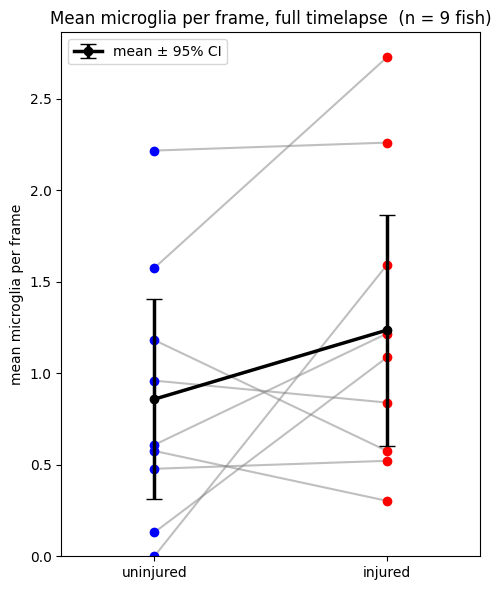

In [10]:
# =====================================================================
# Cell 6 — Paired per-fish comparison: uninjured vs injured
# ---------------------------------------------------------------------
# One dot per fish per region, connected. Metric = MEAN microglia present
# per frame over the WHOLE timelapse (cadence- and duration-independent):
#     (spots in region across all frames) / (n_frames for that image)
# Exploratory: NO hypothesis test. The black line is the group mean with a
# 95% confidence interval (t-based) at each end.
# Reminder: raw counts, NOT area-normalised (region-size confound).
# =====================================================================
from scipy import stats   # used only for the t-multiplier of the CI, not a test

totals = (spots[spots["region"].isin(["uninjured", "injured"])]
          .groupby(["SOURCE_IMAGE", "region"]).size()
          .unstack("region")
          .reindex(columns=["uninjured", "injured"])
          .fillna(0))
per_fish = totals.div(per_image["n_frames"], axis=0)      # mean cells/frame per region

# group means and 95% CI  (mean +/- t* x SEM, df = n-1)
n     = len(per_fish)
means = per_fish[["uninjured", "injured"]].mean()
sems  = per_fish[["uninjured", "injured"]].sem()          # std / sqrt(n), ddof=1
ci95  = stats.t.ppf(0.975, df=n - 1) * sems

fig, ax = plt.subplots(figsize=(5, 6))
for _, row in per_fish.iterrows():                        # one connector per fish
    ax.plot([0, 1], [row["uninjured"], row["injured"]],
            "-", color="grey", alpha=0.5, zorder=1)
ax.scatter([0]*n, per_fish["uninjured"], color=COLORS["uninjured"], zorder=2)
ax.scatter([1]*n, per_fish["injured"],   color=COLORS["injured"],   zorder=2)
ax.errorbar([0, 1], means.values, yerr=ci95.values,       # group mean + 95% CI
            fmt="-o", color="black", lw=2.5, capsize=6, zorder=3,
            label="mean \u00b1 95% CI")

ax.set_title(f"Mean microglia per frame, full timelapse  (n = {n} fish)")
ax.set_xticks([0, 1]); ax.set_xticklabels(["uninjured", "injured"])
ax.set_ylabel("mean microglia per frame")
ax.set_xlim(-0.4, 1.4); ax.set_ylim(bottom=0)
ax.legend()
fig.tight_layout()
plt.show()

In [13]:
# =====================================================================
# Cell 7 — Build the per-track motility table
# ---------------------------------------------------------------------
# Joins onto TrackMate's track features the things it doesn't carry:
#   * region_fine per track (core / penumbra / uninjured / outside)
#   * fraction_manual (curator-placed spots)
#   * DIRECTIONALITY toward the injury: TrackMate gives displacement
#     MAGNITUDE only. Because Step 04 standardised injury-to-TOP, "toward
#     injury" = decreasing Y, so we compute net Y travel from the spots.
#
# Track identity = (SOURCE_IMAGE, TRACK_ID). We consume TrackMate's
# kinematics as-is (no interpolation); we only ADD columns.
# =====================================================================

# ---- knobs -----------------------------------------------------------
MIN_SPOTS        = 5          # drop tracks shorter than this (noisy kinematics)
MAX_GAPS_ALLOWED = None       # None = keep all; e.g. 0 = gap-free tracks only
REGION_RULE      = "majority" # "majority" = zone of most spots
                              # "end"      = zone at the track's LAST frame
                              # "deepest"  = most-injured zone it EVER entered
INJURY_AT_TOP    = True       # Step 04 standardises injury to TOP (small Y),
                              # so toward-injury = decreasing Y. Flip if not.

KEYS       = ["SOURCE_IMAGE", "TRACK_ID"]
FINE_ORDER = ["core", "penumbra", "uninjured", "outside"]

# ---- 1) per-track region composition (FINE granularity) --------------
reg_counts = (spots.groupby(KEYS)["region_fine"]
                   .value_counts().unstack(fill_value=0)
                   .reindex(columns=FINE_ORDER, fill_value=0))
reg_frac = reg_counts.div(reg_counts.sum(axis=1), axis=0)
reg_frac.columns = [f"frac_{c}" for c in reg_frac.columns]

# ---- 1b) single region label per the chosen rule ---------------------
if REGION_RULE == "majority":
    region_track = reg_counts.idxmax(axis=1).rename("region_track")
elif REGION_RULE == "end":
    region_track = (spots.sort_values("FRAME").groupby(KEYS).tail(1)
                         .set_index(KEYS)["region_fine"].rename("region_track"))
elif REGION_RULE == "deepest":
    # highest-severity zone ever occupied (core>penumbra>uninjured>outside via label value)
    region_track = (spots.groupby(KEYS)["MEDIAN_INTENSITY_CH5"].max()
                         .map(REGION_FINE).rename("region_track"))
else:
    raise ValueError("REGION_RULE must be 'majority', 'end' or 'deepest'")

# ---- 2) fraction of each track's spots that were MANUAL ---------------
frac_manual = spots.groupby(KEYS)["is_manual"].mean().rename("fraction_manual")

# ---- 3) DIRECTIONALITY toward the injury (computed from spots) --------
ordered = spots.sort_values("FRAME")
first   = ordered.groupby(KEYS)[["POSITION_X", "POSITION_Y"]].first()
last    = ordered.groupby(KEYS)[["POSITION_X", "POSITION_Y"]].last()
dxy = last - first
net_disp = np.hypot(dxy["POSITION_X"], dxy["POSITION_Y"]).rename("net_disp_um")
toward   = (-dxy["POSITION_Y"] if INJURY_AT_TOP else dxy["POSITION_Y"]).rename("toward_injury_um")
# directedness in [-1, 1]: +1 = straight at injury, -1 = straight away, ~0 = sideways/none
directedness = (toward / net_disp).replace([np.inf, -np.inf], np.nan).rename("directedness")
direction = pd.concat([net_disp, toward, directedness], axis=1)

# ---- 4) merge everything onto TrackMate's track features --------------
per_track = (tracks
             .merge(region_track.reset_index(), on=KEYS)
             .merge(reg_frac.reset_index(),     on=KEYS)
             .merge(frac_manual.reset_index(),  on=KEYS)
             .merge(direction.reset_index(),    on=KEYS))

# derived flags
per_track["frac_injured_side"] = per_track["frac_core"] + per_track["frac_penumbra"]
per_track["reaches_core"]      = per_track["frac_core"] > 0
per_track["is_migrator"]       = ((per_track["frac_uninjured"] > 0) &
                                  (per_track["frac_injured_side"] > 0))

# ---- 5) quality knobs -------------------------------------------------
n_before = len(per_track)
keep = per_track["NUMBER_SPOTS"] >= MIN_SPOTS
if MAX_GAPS_ALLOWED is not None:
    keep &= per_track["NUMBER_GAPS"] <= MAX_GAPS_ALLOWED
per_track = per_track[keep].copy()

# ---- 6) report --------------------------------------------------------
print(f"tracks: {n_before} -> {len(per_track)} kept "
      f"(MIN_SPOTS={MIN_SPOTS}, MAX_GAPS_ALLOWED={MAX_GAPS_ALLOWED}, REGION_RULE='{REGION_RULE}')")
print("\nregion_track counts (kept):")
print(per_track["region_track"].value_counts())
print(f"\nmigrators (uninjured <-> injured side): {int(per_track['is_migrator'].sum())}")
print(f"tracks reaching the core: {int(per_track['reaches_core'].sum())}")

per_track[KEYS + ["region_track", "frac_uninjured", "frac_penumbra", "frac_core",
                  "is_migrator", "reaches_core", "fraction_manual", "NUMBER_SPOTS",
                  "toward_injury_um", "directedness", "CONFINEMENT_RATIO",
                  "MEAN_STRAIGHT_LINE_SPEED"]].head(12)

tracks: 30 -> 25 kept (MIN_SPOTS=5, MAX_GAPS_ALLOWED=None, REGION_RULE='majority')

region_track counts (kept):
region_track
uninjured    9
core         6
penumbra     6
outside      4
Name: count, dtype: int64

migrators (uninjured <-> injured side): 12
tracks reaching the core: 15


,SOURCE_IMAGE,TRACK_ID,region_track,frac_uninjured,frac_penumbra,frac_core,is_migrator,reaches_core,fraction_manual,NUMBER_SPOTS,toward_injury_um,directedness,CONFINEMENT_RATIO,MEAN_STRAIGHT_LINE_SPEED
1,20250724_20250724_Position001_20250724_2025072...,8,core,0.000000,0.217391,0.782609,False,True,0.000000,23.0,-0.620647,-0.008023,0.531370,0.001465
2,20250724_20250724_Position005_20250724_2025072...,1,uninjured,0.478261,0.260870,0.260870,True,True,0.000000,23.0,2.324946,0.026611,0.351886,0.001655
3,20250724_20250724_Position007_20250724_2025072...,0,uninjured,0.739130,0.086957,0.173913,True,True,0.130435,23.0,-9.257876,-0.165076,0.294289,0.001062
4,20250724_20250724_Position007_20250724_2025072...,2,uninjured,1.000000,0.000000,0.000000,False,False,0.263158,19.0,-2.944578,-0.077402,0.161580,0.000834
5,20250724_20250724_Position007_20250724_2025072...,7,penumbra,0.000000,0.562500,0.437500,False,True,0.000000,16.0,13.716893,0.879423,0.076644,0.000433
6,20250724_20250724_Position007_20250724_2025072...,44,outside,0.000000,0.000000,0.000000,False,False,0.222222,9.0,-1.972054,-0.150337,0.204594,0.000683
7,20250724_20250724_Position007_20250724_2025072...,45,core,0.000000,0.260870,0.739130,False,True,0.565217,23.0,14.204558,0.934784,0.123882,0.000288
8,20250724_20250724_Position007_20250724_2025072...,47,uninjured,0.608696,0.130435,0.000000,True,False,0.391304,23.0,-25.303399,-0.685398,0.300554,0.000699
11,20250724_20250724_Position008_20250724_2025072...,20,uninjured,0.631579,0.157895,0.000000,True,False,0.157895,19.0,28.565808,0.152126,0.857721,0.004347
12,20250724_20250724_Position008_20250724_2025072...,22,core,0.000000,0.304348,0.695652,False,True,0.260870,23.0,25.738005,0.381521,0.381825,0.001278


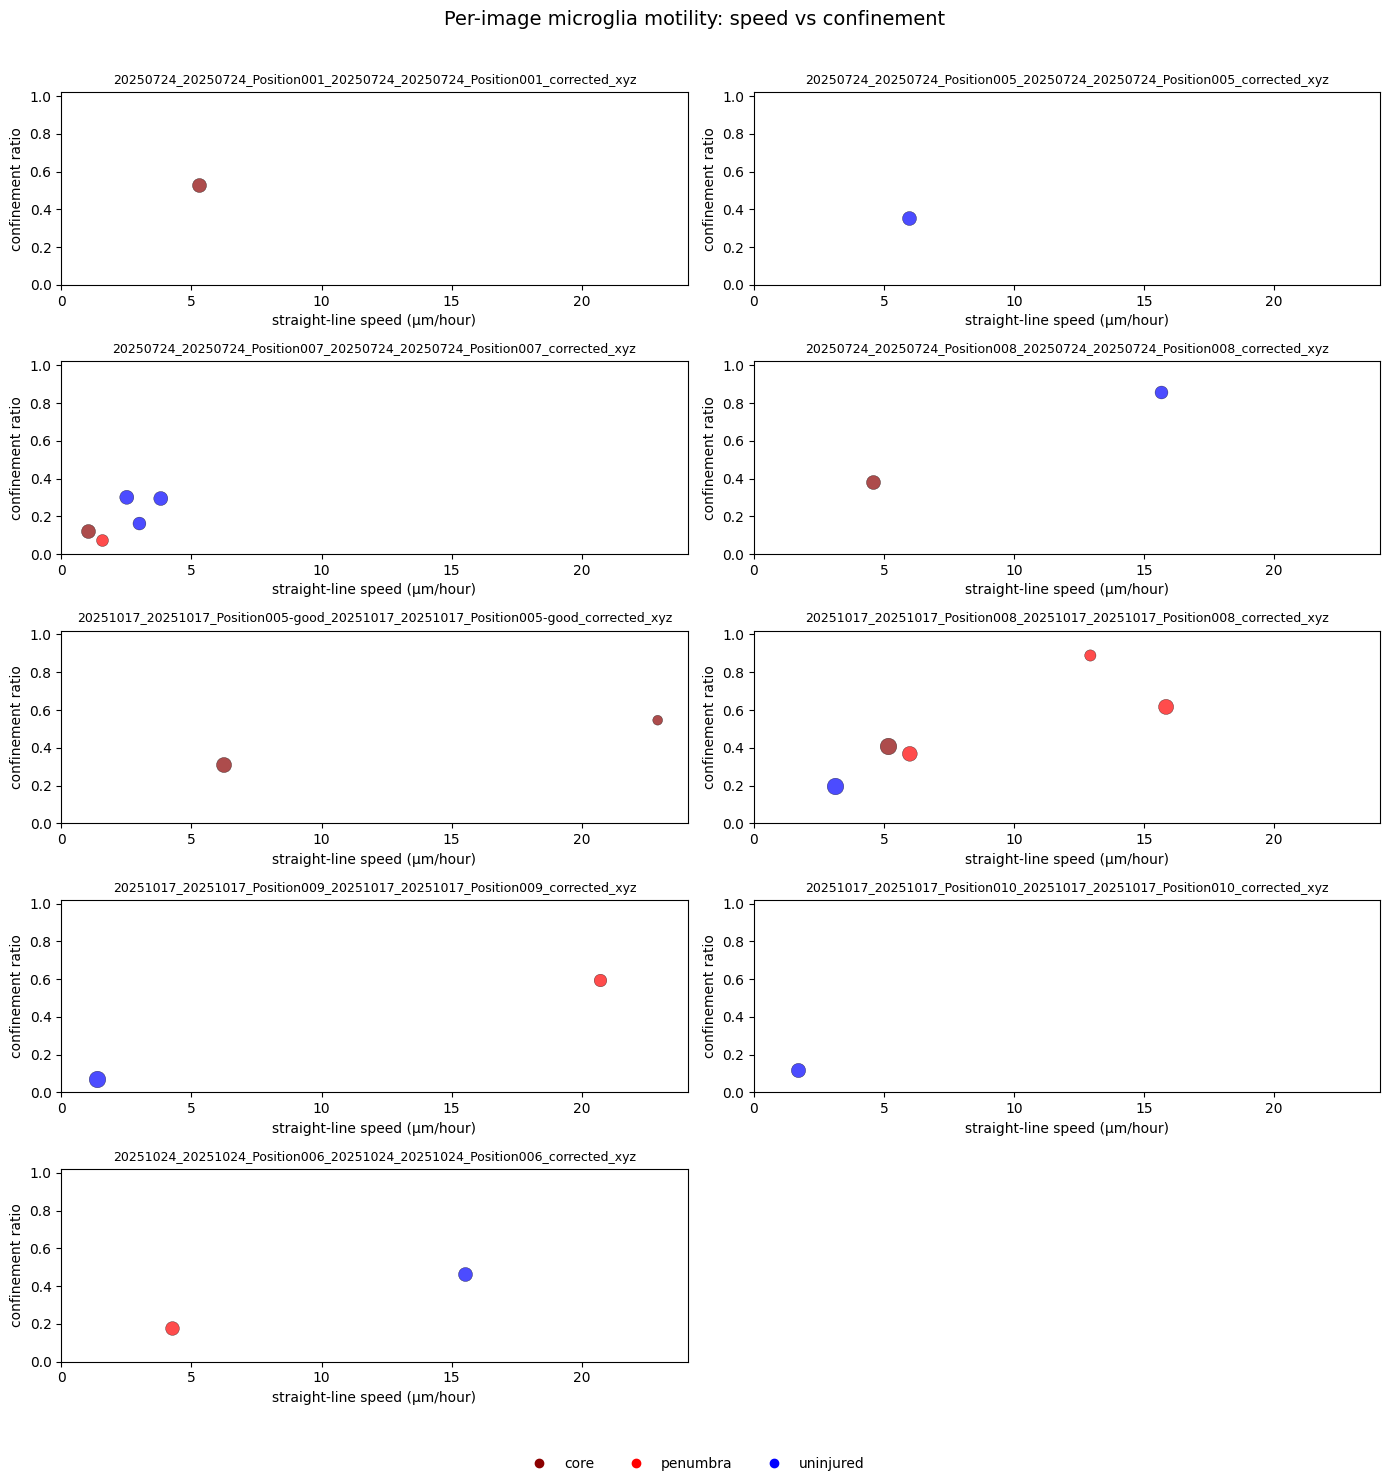

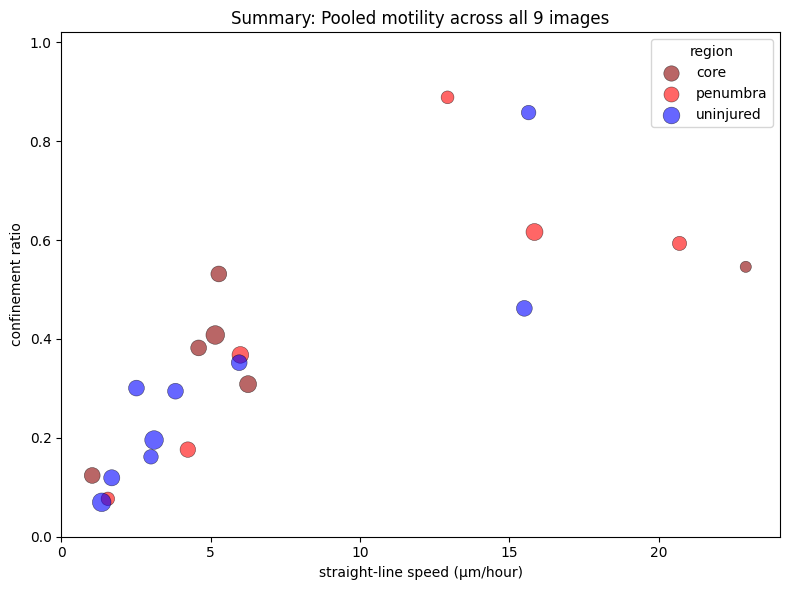

In [20]:
# =====================================================================
# Cell 8 — Per-image and Summary motility: speed vs confinement
# ---------------------------------------------------------------------
# x = MEAN_STRAIGHT_LINE_SPEED  (cadence-ROBUST: net displacement / time)
# y = CONFINEMENT_RATIO         (0 = confined/stays put, 1 = directed)
# colour = track's fine region:  core = dark red, penumbra = red,
#          uninjured = blue. 'outside' tracks are excluded.
# marker size ~ track length, so short/noisy tracks are visibly smaller.
#
# A cell "stopping in the injured CORE" = a DARK-RED dot in the BOTTOM-LEFT
# (low speed AND low confinement) — that's the shape your hypothesis predicts.
# =====================================================================
SPEED_COL   = "MEAN_STRAIGHT_LINE_SPEED"
TO_PER_HOUR = 3600.0     # TrackMate speed is um/s; x3600 -> um/hour (readable)
NCOLS       = 2

# motility uses the FINE regions; give them their own gradient colours
MOT_ORDER  = ["core", "penumbra", "uninjured"]
MOT_COLORS = {"core": "darkred", "penumbra": "red", "uninjured": "blue"}

plot_df    = per_track[per_track["region_track"].isin(MOT_ORDER)]
mot_images = sorted(plot_df["SOURCE_IMAGE"].unique())   # local name; don't clobber `images`
xmax       = plot_df[SPEED_COL].max() * TO_PER_HOUR * 1.05

# --- Part A: Small Multiples (One panel per image) ---
nrows = int(np.ceil(len(mot_images) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS, figsize=(7 * NCOLS, 3 * nrows))
axes = axes.ravel()

for ax, img in zip(axes, mot_images):
    sub = plot_df[plot_df["SOURCE_IMAGE" ] == img]
    for grp in MOT_ORDER:
        g = sub[sub["region_track"] == grp]
        ax.scatter(g[SPEED_COL] * TO_PER_HOUR, g["CONFINEMENT_RATIO"],
                   s=10 + 4 * g["NUMBER_SPOTS"], color=MOT_COLORS[grp],
                   alpha=0.7, edgecolor="k", linewidth=0.3, label=grp)
    ax.set_title(img, fontsize=9)
    ax.set_xlabel("straight-line speed (\u00b5m/hour)")
    ax.set_ylabel("confinement ratio")
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, 1.02)

for ax in axes[len(mot_images):]:
    ax.axis("off")

handles = [plt.Line2D([], [], marker="o", ls="", color=MOT_COLORS[g], label=g)
           for g in MOT_ORDER]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False)
fig.suptitle("Per-image microglia motility: speed vs confinement", fontsize=14)
fig.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

# --- Part B: Pooled Summary (All images together) ---
fig_sum, ax_sum = plt.subplots(figsize=(8, 6))
for grp in MOT_ORDER:
    g = plot_df[plot_df["region_track"] == grp]
    ax_sum.scatter(g[SPEED_COL] * TO_PER_HOUR, g["CONFINEMENT_RATIO"],
                   s=15 + 5 * g["NUMBER_SPOTS"], color=MOT_COLORS[grp],
                   alpha=0.6, edgecolor="k", linewidth=0.4, label=grp)

ax_sum.set_title(f"Summary: Pooled motility across all {len(mot_images)} images", fontsize=12)
ax_sum.set_xlabel("straight-line speed (\u00b5m/hour)")
ax_sum.set_ylabel("confinement ratio")
ax_sum.set_xlim(0, xmax)
ax_sum.set_ylim(0, 1.02)
ax_sum.legend(title="region")
fig_sum.tight_layout()
plt.show()

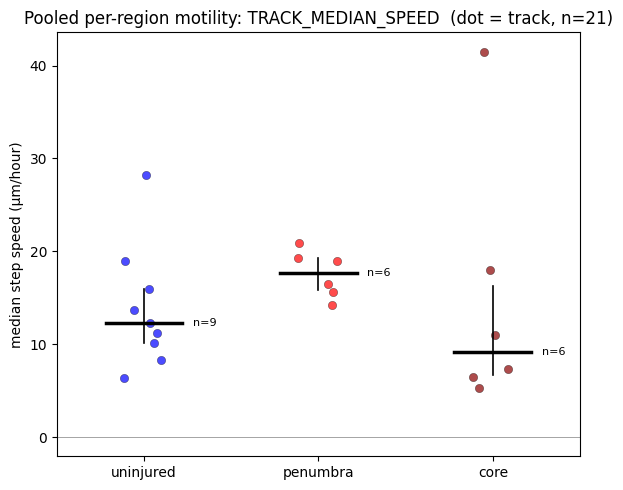

In [16]:
# =====================================================================
# Cell 9 — Pooled per-region motility (all tracks together)
# ---------------------------------------------------------------------
# The simplest aggregate: pool every track across all images and compare
# ONE metric across the injury gradient (uninjured -> penumbra -> core).
# One dot = one track (coloured by region_track), jittered; the black bar
# is the group median with the inter-quartile range.
#
# Default metric = TRACK_MEDIAN_SPEED (your "median jump", but per-time so
# it's cadence-comparable). Swap METRIC to compare confinement /
# directedness / toward_injury_um — it's just a column name.
#
# Caveat: pooling treats every track equally and ignores that tracks are
# nested in fish (a fish-level effect) — fine for exploration, not a final stat.
# =====================================================================
METRIC     = "TRACK_MEDIAN_SPEED"   # try: CONFINEMENT_RATIO, directedness, toward_injury_um
SCALE      = 3600.0                 # um/s -> um/hour for speed metrics (use 1.0 otherwise)
YLABEL     = "median step speed (\u00b5m/hour)"
REGIONS    = ["uninjured", "penumbra", "core"]   # gradient order, left -> right
MOT_COLORS = {"core": "darkred", "penumbra": "red", "uninjured": "blue"}

pdf = per_track[per_track["region_track"].isin(REGIONS)].copy()
pdf["_y"] = pdf[METRIC] * SCALE

rng = np.random.default_rng(0)       # reproducible jitter
fig, ax = plt.subplots(figsize=(6, 5))
for i, grp in enumerate(REGIONS):
    g = pdf.loc[pdf["region_track"] == grp, "_y"].dropna()
    ax.scatter(i + rng.uniform(-0.12, 0.12, len(g)), g, color=MOT_COLORS[grp],
               alpha=0.7, edgecolor="k", linewidth=0.3, zorder=2)
    if len(g):                       # median (thick) + IQR (thin) bar
        med = g.median(); q1, q3 = g.quantile([0.25, 0.75])
        ax.plot([i-0.22, i+0.22], [med, med], color="k", lw=2.5, zorder=3)
        ax.plot([i, i], [q1, q3], color="k", lw=1.2, zorder=3)
        ax.text(i+0.28, med, f"n={len(g)}", va="center", fontsize=8)

ax.axhline(0, color="grey", lw=0.5)  # meaningful when METRIC can go negative (directedness)
ax.set_xticks(range(len(REGIONS))); ax.set_xticklabels(REGIONS)
ax.set_ylabel(YLABEL)
ax.set_xlim(-0.5, len(REGIONS)-0.5)
ax.set_title(f"Pooled per-region motility: {METRIC}  (dot = track, n={len(pdf)})")
fig.tight_layout()
plt.show()

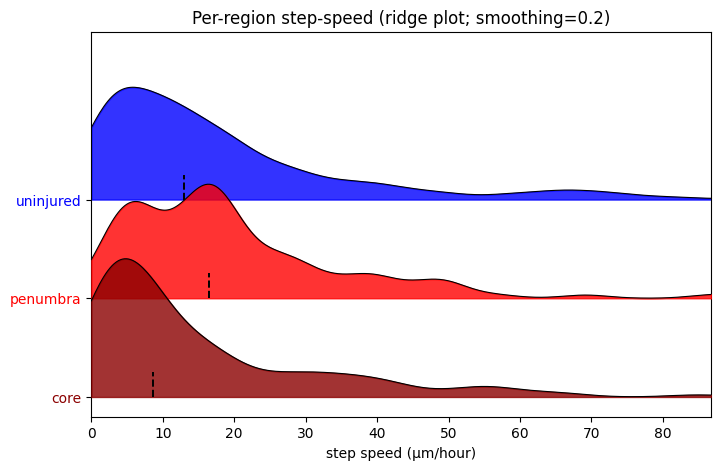

In [22]:
# =====================================================================
# Cell 10 — Per-region step-speed RIDGE plot
# ---------------------------------------------------------------------
# Same per-step data as before (frame-to-frame jump as a SPEED in m/hour,
# pooled across images, attributed to the region at the START of the step),
# drawn as three overlapping ridges so the distribution SHAPES stack for
# easy comparison. Dashed tick = each region's median.
# =====================================================================
from scipy.stats import gaussian_kde

REGIONS    = ["uninjured", "penumbra", "core"]   # top -> bottom of the ridge
MOT_COLORS = {"core": "darkred", "penumbra": "red", "uninjured": "blue"}
EXCLUDE_GAP_STEPS = False
OVERLAP    = 1.4      # ridge height vs row spacing
SMOOTHING  = 0.2      # <--- ADJUST THIS for smoothing (e.g., 0.1 to 0.5)

# ---- recompute per-step speeds (self-contained) ----------------------
s   = spots.merge(per_track[KEYS].drop_duplicates(), on=KEYS, how="inner")
s   = s.sort_values(KEYS + ["FRAME"])
grp = s.groupby(KEYS, sort=False)
s["dist_um"]      = np.hypot(grp["POSITION_X"].diff(), grp["POSITION_Y"].diff())
s["dt_s"]         = grp["POSITION_T"].diff()
s["dframe"]       = grp["FRAME"].diff()
s["region_start"] = grp["region_fine"].shift()
steps = s.dropna(subset=["dist_um", "dt_s", "region_start"])
steps = steps[steps["dt_s"] > 0]
if EXCLUDE_GAP_STEPS:
    steps = steps[steps["dframe" ] == 1]
steps = steps.assign(speed_um_hour=steps["dist_um"] / steps["dt_s"] * 3600.0)

# ---- build the ridges ------------------------------------------------
vmax = np.nanpercentile(steps["speed_um_hour"], 99)
xs   = np.linspace(0, vmax, 300)
n    = len(REGIONS)

# KDE per region, applying the SMOOTHING factor to bw_method
dens = {}
for r in REGIONS:
    v = steps.loc[steps["region_start" ] == r, "speed_um_hour"].dropna().values
    if (len(v) >= 2 and np.std(v) > 0):
        dens[r] = gaussian_kde(v, bw_method=SMOOTHING)(xs)
    else:
        dens[r] = np.zeros_like(xs)

gmax = max((d.max() for d in dens.values()), default=1.0) or 1.0

fig, ax = plt.subplots(figsize=(8, 5))
for idx, r in enumerate(REGIONS):
    base = n - 1 - idx
    d    = dens[r] / gmax * OVERLAP
    z    = idx + 2
    ax.fill_between(xs, base, base + d, color=MOT_COLORS[r], alpha=0.8, zorder=z)
    ax.plot(xs, base + d, color="k", lw=0.8, zorder=z)
    v = steps.loc[steps["region_start"] == r, "speed_um_hour"].dropna()
    if len(v):
        ax.plot([v.median()] * 2, [base, base + 0.18 * OVERLAP],
                color="k", lw=1.4, ls="--", zorder=z + 0.1)

ax.set_yticks([n - 1 - i for i in range(n)])
ax.set_yticklabels(REGIONS)
for tick, r in zip(ax.get_yticklabels(), REGIONS):
    tick.set_color(MOT_COLORS[r])
ax.set_ylim(-0.2, n - 1 + OVERLAP + 0.3)
ax.set_xlim(0, vmax)
ax.set_xlabel("step speed (\u00b5m/hour)")
ax.set_title(f"Per-region step-speed (ridge plot; smoothing={SMOOTHING})")
plt.show()